BREAK


In [1]:
!pip install kagglehub transformers datasets torch torchvision accelerate scikit-learn matplotlib

In [2]:
#Dependencies
import kagglehub, os, torch, copy, collections
import numpy as np
from pathlib import Path
from transformers import AutoFeatureExtractor, AutoModelForImageClassification
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import classification_report
from PIL import Image

In [3]:
#Download the dataset
img_path = kagglehub.dataset_download("marcosvolpato/edible-and-poisonous-fungi")
print("Downloaded to:", img_path)

#Print out the folder structure
for root, dirs, files in os.walk(img_path):
    level = root.replace(img_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/ ({len(files)} files)')

100%|██████████| 257M/257M [00:07<00:00, 38.2MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/marcosvolpato/edible-and-poisonous-fungi/versions/1
1/ (0 files)
  poisonous sporocarp/ (1360 files)
  edible sporocarp/ (466 files)
  edible mushroom sporocarp/ (715 files)
  poisonous mushroom sporocarp/ (860 files)


In [5]:
import shutil, os

#Just another check to ensure a clean state
dest_base = "/content/mushrooms"
shutil.rmtree(dest_base, ignore_errors=True)  # clear old attempt
os.makedirs(f"{dest_base}/edible",    exist_ok=True)
os.makedirs(f"{dest_base}/poisonous", exist_ok=True)

src = "/root/.cache/kagglehub/datasets/marcosvolpato/edible-and-poisonous-fungi/versions/1"

#We want to consolidate the edible mushroom images into one folder "edible"
for folder in ["edible sporocarp", "edible mushroom sporocarp"]:
    for f in os.listdir(os.path.join(src, folder)):
        shutil.copy(os.path.join(src, folder, f), f"{dest_base}/edible/{f}")
#Same concept but for poisinous
for folder in ["poisonous sporocarp", "poisonous mushroom sporocarp"]:
    for f in os.listdir(os.path.join(src, folder)):
        shutil.copy(os.path.join(src, folder, f), f"{dest_base}/poisonous/{f}")
#Print number of images in each folder
for cls in ["edible", "poisonous"]:
    print(f"{cls}/: {len(os.listdir(f'{dest_base}/{cls}'))} files")

edible/: 1181 files
poisonous/: 2220 files


In [6]:
#Adding augmentation to enable the model to learn general features
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(45),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
#Ensure correct formatting for the model
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

full_ds = datasets.ImageFolder(root=dest_base)
print("Classes:", full_ds.classes)
print("Total images:", len(full_ds))

#Train, Validation, Test split we want a 70-15-15 training split here
n       = len(full_ds)
n_train = int(0.7 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val

train_ds, val_ds, test_ds = torch.utils.data.random_split(full_ds, [n_train, n_val, n_test])

train_ds.dataset.transform = transform_train
val_ds.dataset.transform   = transform_val
#The dataloaders are what feed the images to the GPU during the training phase
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)

Classes: ['edible', 'poisonous']
Total images: 3401


In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

#Loading the model (ResNet-50)
model = AutoModelForImageClassification.from_pretrained(
    "microsoft/resnet-50",
    num_labels=len(full_ds.classes),
    ignore_mismatched_sizes=True
).to(device)

#Create the label map, 0: "edible", 1: "poisinous"
id2label = {i: c for i, c in enumerate(full_ds.classes)}
print("id2label:", id2label)

Using: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

ResNetForImageClassification LOAD REPORT from: microsoft/resnet-50
Key                 | Status   |                                                                                          
--------------------+----------+------------------------------------------------------------------------------------------
classifier.1.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 2048]) vs model:torch.Size([2, 2048])
classifier.1.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])            

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


id2label: {0: 'edible', 1: 'poisonous'}


In [8]:
#Lock all layers except for the final classifier layer (fine-tuning)
for name, param in model.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False
#Optimizer to make training go faster
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

# Weighted loss to handle 1181 edible vs 2220 poisonous imbalance
counts  = [len(os.listdir(f"{dest_base}/{c}")) for c in full_ds.classes]
weights = torch.tensor([1.0 / c for c in counts]).to(device)
weights = weights / weights.sum()
criterion = torch.nn.CrossEntropyLoss(weight=weights)

print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Trainable params: 4098


In [12]:
best_val_loss = float("inf")
best_weights  = None

#Train the model
for epoch in range(30):
    model.train()
    train_loss, correct, total = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs).logits
        loss   = criterion(logits, labels)
        loss.backward(); optimizer.step()
        train_loss += loss.item()
        correct    += (logits.argmax(-1) == labels).sum().item()
        total      += labels.size(0)
#Validation Phase
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits        = model(imgs).logits
            val_loss     += criterion(logits, labels).item()
            val_correct  += (logits.argmax(-1) == labels).sum().item()
            val_total    += labels.size(0)

    avg_val = val_loss / len(val_loader)
    print(f"Epoch {epoch+1:2d} | "
          f"train loss: {train_loss/len(train_loader):.4f} acc: {correct/total*100:.1f}% | "
          f"val loss: {avg_val:.4f} acc: {val_correct/val_total*100:.1f}%")
#Saving the best weights
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        best_weights  = copy.deepcopy(model.state_dict())
        torch.save(best_weights, "/content/best_mushroom_resnet.pt")
        print("  -> saved best model")

model.load_state_dict(best_weights)
print("Training complete — best weights restored")

Epoch  1 | train loss: 0.5645 acc: 74.9% | val loss: 0.5805 acc: 72.5%
  -> saved best model
Epoch  2 | train loss: 0.5630 acc: 74.4% | val loss: 0.5812 acc: 74.1%
Epoch  3 | train loss: 0.5537 acc: 75.8% | val loss: 0.5800 acc: 74.3%
  -> saved best model
Epoch  4 | train loss: 0.5537 acc: 75.1% | val loss: 0.5788 acc: 73.7%
  -> saved best model
Epoch  5 | train loss: 0.5495 acc: 76.1% | val loss: 0.5807 acc: 73.7%
Epoch  6 | train loss: 0.5469 acc: 75.9% | val loss: 0.5727 acc: 74.7%
  -> saved best model
Epoch  7 | train loss: 0.5473 acc: 75.9% | val loss: 0.5732 acc: 74.1%
Epoch  8 | train loss: 0.5410 acc: 76.1% | val loss: 0.5719 acc: 75.1%
  -> saved best model
Epoch  9 | train loss: 0.5434 acc: 76.1% | val loss: 0.5697 acc: 74.1%
  -> saved best model
Epoch 10 | train loss: 0.5391 acc: 76.0% | val loss: 0.5662 acc: 74.5%
  -> saved best model
Epoch 11 | train loss: 0.5324 acc: 76.3% | val loss: 0.5687 acc: 74.5%
Epoch 12 | train loss: 0.5336 acc: 75.9% | val loss: 0.5631 acc: 

In [13]:
#Load the weights if training takes too long
from google.colab import files
import torch

print("Select the 'best_mushroom_resnet.pt' file")
uploaded_weights = files.upload()  # opens a file picker dialog

weight_filename = list(uploaded_weights.keys())[0]
state_dict = torch.load(
    weight_filename,
    map_location=device,
    weights_only=True
)
model.load_state_dict(state_dict)
model.to(device)
print(f"Weights loaded from '{weight_filename}' ")

Select your 'best_mushroom_resnet.pt' file...


Saving best_mushroom_resnet.pt to best_mushroom_resnet (1).pt
✅ Weights loaded from 'best_mushroom_resnet (1).pt' — ready to evaluate.


In [10]:
model.eval()
all_preds, all_labels = [], []

#loop through the validation set again using the best weights
with torch.no_grad():
    for imgs, labels in val_loader:
        preds = model(imgs.to(device)).logits.argmax(-1)
        all_preds  += preds.cpu().tolist()
        all_labels += labels.tolist()
#
print(classification_report(all_labels, all_preds, target_names=full_ds.classes))

              precision    recall  f1-score   support

      edible       0.63      0.74      0.68       196
   poisonous       0.82      0.73      0.77       314

    accuracy                           0.73       510
   macro avg       0.72      0.74      0.73       510
weighted avg       0.75      0.73      0.74       510



Saving amanita-feature.jpg to amanita-feature.jpg


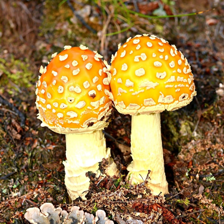

In [11]:
from google.colab import files
import io, IPython.display as display

#Upload an image
uploaded = files.upload()

for filename, data in uploaded.items():
    img = Image.open(io.BytesIO(data)).convert("RGB")
    display.display(img.resize((224, 224)))

#Format the image for the model
    model.eval()
    t = transform_val(img).unsqueeze(0).to(device)
    with torch.no_grad():
      #Calculate the probability
        probs = torch.softmax(model(t).logits, dim=-1)[0]
#Pick the class with the highest proabability
    pred       = probs.argmax().item()
    confidence = probs[pred].item() * 100
    label      = id2label[pred]

    color = "red" if label == "poisonous" else "green"
    display.display(display.HTML(
        f'<h2 style="color:{color}">{label.upper()} ({confidence:.1f}% confidence)</h2>'
    ))